# Step 6, Part B — Online RL: PPO-Lagrangian
### Step 5 of the guide: the Lagrangian safety loop

**Continues from `Step6B_PlainPPO_SanityCheck.ipynb`**, which fine-tuned the DT-warm-started policy
with ordinary reward-only PPO on **TRAIN** and confirmed the environment and warm start genuinely
support learning. That notebook saved the resulting policy as `ppo_plain_finetuned.zip` — that is
exactly where this notebook picks up.

**What this notebook does:** wraps the environment so the reward the agent actually optimizes
during training becomes `reward - lambda * cost`, and calibrates `lambda` automatically with a
dual-ascent loop — `lambda` rises when the policy's average cost is above the budget and falls
(floored at 0) when it's below. This is the mechanism that makes this **PPO-Lagrangian** rather
than plain reward shaping with a hand-picked penalty constant, and it is the step that actually
starts training against the constraint violations that the previous notebook only observed.

**Two deliberate deviations from the guide's reference pseudocode, both explained where they
happen below (not glossed over):**
1. **Starting point** — the guide's Step 5 snippet instantiates a *fresh* `PPO(...)`. This
   notebook instead continues from `ppo_plain_finetuned.zip`, the model this project has already
   built and validated. Discarding it and starting from scratch would throw away both the offline
   Decision-Transformer warm start (Part A) and the confirmed-working plain-PPO fine-tuning
   (Step 4) — there is no reason to pay that cost again.
2. **`lam_lr`** — kept at `20.0`, the value this project's cost signal was originally found to need
   (the guide's own default of `0.02` assumes a cost signal on reward's own scale, which does not
   hold here). Cell 8/9's diagnostic below is re-run in full on TRAIN's own actual reward/cost
   numbers before training starts, specifically so `lam_lr=20.0` is *checked* against the new data
   rather than silently carried over — if the diagnostic below shows the cost/reward relationship
   has shifted materially from what originally justified `20.0` (TRAIN's much larger realistic
   drawdowns make this plausible), adjust `lam_lr` from that fresh number before running the loop,
   using the same reasoning laid out in cell 10 below.

**Everything else matches the guide's Part B, Step 5 exactly**: the `LambdaPenalizedEnv` reward
wrapper, the dual-ascent update rule `lambda <- max(0, lambda + lam_lr * (avg_cost - cost_budget))`,
and the diagnostic questions it recommends watching for while the loop runs.


## Setup — rebuild the environment exactly as before, load the plain-PPO-finetuned policy

Identical data loading and `PortfolioAdjustEnv` definition to `Step6A_WarmStart_PPO.ipynb` and
`Step6B_PlainPPO_SanityCheck.ipynb` (TRAIN, 2018-01-03 to 2024-12-31, 1,758 days, same 12-dim
state, `cvar_budget=0.023` / `drawdown_budget=0.19`, recalibrated in Part A from the anchor
policy's own real risk distribution over TRAIN). Rebuilding it here rather than importing it keeps
this notebook self-contained and runnable on its own, matching the pattern of every notebook so
far.


In [1]:
!pip install --quiet --break-system-packages gymnasium stable-baselines3
# torch/pandas/numpy ship preinstalled in Colab; uncomment below if running in a bare local
# environment instead:
# !pip install --quiet --break-system-packages torch pandas numpy matplotlib


In [2]:
import pickle
import numpy as np
import pandas as pd
import gymnasium as gym
from stable_baselines3 import PPO

np.random.seed(42)

with open("offline_trajectories.pkl", "rb") as f:
    saved = pickle.load(f)
ASSETS = saved["assets"]
STATE_DIM = saved["state_dim"]

df = pd.read_csv("project8_dataset_v2.csv", parse_dates=["Date"], index_col="Date")
prices = df[[f"{a}_Close" for a in ASSETS]].copy()
prices.columns = ASSETS
prices = prices.dropna()
returns = prices.pct_change().dropna()
returns_clean = returns.clip(lower=-0.20, upper=0.20)

train_dates = df[df["PERIOD"] == "TRAIN"].index
train_rets = returns_clean.loc[returns_clean.index.isin(train_dates)]

anchor = pd.read_csv("bl_baseline_train_weights.csv", parse_dates=["Date"]).set_index("Date")
daily_anchor = anchor.reindex(train_rets.index, method="ffill").bfill()
assert len(train_rets) == 1758

CVAR_WINDOW = 60
N_STEPS = len(train_rets) - CVAR_WINDOW - 1


def build_state_features(t_idx):
    if t_idx < 5:
        trailing = train_rets.iloc[:t_idx] if t_idx > 0 else train_rets.iloc[:1] * 0
    else:
        trailing = train_rets.iloc[t_idx - 5:t_idx]
    mean_ret = trailing[ASSETS].mean().values if len(trailing) > 0 else np.zeros(len(ASSETS))
    vol = trailing[ASSETS].std().fillna(0).values if len(trailing) > 0 else np.zeros(len(ASSETS))
    w = daily_anchor.iloc[t_idx][ASSETS].values
    return np.concatenate([mean_ret, vol, w]).astype(np.float32)


def compute_cvar(returns_arr, alpha=0.05):
    """Historical-simulation CVaR: average loss in the worst alpha fraction of periods."""
    losses = -returns_arr
    var_threshold = np.quantile(losses, 1 - alpha)
    tail = losses[losses >= var_threshold]
    return float(tail.mean()) if len(tail) > 0 else float(losses.max())


class PortfolioAdjustEnv(gym.Env):
    # identical to Step6A_WarmStart_PPO.ipynb / Step6B_PlainPPO_SanityCheck.ipynb, including the
    # TRAIN-recalibrated CVaR + drawdown budgets
    def __init__(self, daily_anchor, train_rets, assets, state_fn, cvar_budget=0.023,
                 cvar_window=60, cvar_alpha=0.05, drawdown_budget=0.19):
        super().__init__()
        self.daily_anchor = daily_anchor
        self.train_rets = train_rets
        self.assets = assets
        self.state_fn = state_fn
        self.cvar_budget = cvar_budget
        self.cvar_window = cvar_window
        self.cvar_alpha = cvar_alpha
        self.drawdown_budget = drawdown_budget
        self.n_assets = len(assets)
        self.state_dim = state_fn(cvar_window).shape[0]

        self.action_space = gym.spaces.Box(low=-0.15, high=0.15, shape=(self.n_assets,), dtype=np.float32)
        self.observation_space = gym.spaces.Box(low=-np.inf, high=np.inf, shape=(self.state_dim,), dtype=np.float32)
        self.t = None
        self.cum_value = None
        self.peak_value = None

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.t = self.cvar_window
        self.cum_value = 1.0
        self.peak_value = 1.0
        return self.state_fn(self.t), {}

    def step(self, action):
        anchor_w = self.daily_anchor.iloc[self.t][self.assets].values
        adjusted = np.clip(anchor_w + np.asarray(action), 0, 1)
        adjusted = adjusted / adjusted.sum()

        reward = float(adjusted @ self.train_rets.iloc[self.t][self.assets].values)

        window_rets = self.train_rets.iloc[self.t - self.cvar_window:self.t][self.assets].values @ adjusted
        cvar = compute_cvar(window_rets, self.cvar_alpha)
        cvar_cost = max(0.0, cvar - self.cvar_budget)

        self.cum_value *= (1 + reward)
        self.peak_value = max(self.peak_value, self.cum_value)
        drawdown = (self.cum_value / self.peak_value) - 1
        drawdown_cost = max(0.0, abs(drawdown) - self.drawdown_budget)

        total_cost = cvar_cost + drawdown_cost

        self.t += 1
        terminated = self.t >= len(self.train_rets) - 1
        obs = self.state_fn(self.t) if not terminated else np.zeros(self.state_dim, dtype=np.float32)
        info = {"cost": total_cost, "cvar_cost": cvar_cost, "drawdown_cost": drawdown_cost,
                "drawdown": drawdown, "portfolio_value": self.cum_value}
        return obs, reward, terminated, False, info


base_env = PortfolioAdjustEnv(daily_anchor, train_rets, ASSETS, build_state_features)
model = PPO.load("ppo_plain_finetuned", env=base_env)
print("Environment rebuilt on TRAIN, plain-PPO-finetuned policy loaded from ppo_plain_finetuned.zip")
print(f"CVaR budget: {base_env.cvar_budget}  |  Drawdown budget: {base_env.drawdown_budget}")
print(f"TRAIN-period episode length: {N_STEPS} days")


Environment rebuilt on TRAIN, plain-PPO-finetuned policy loaded from ppo_plain_finetuned.zip
CVaR budget: 0.023  |  Drawdown budget: 0.19
TRAIN-period episode length: 1697 days


## Evaluation helper

The environment is fully deterministic given a fixed action sequence (same insight already
established in `Step6B_PlainPPO_SanityCheck.ipynb`), so one deterministic rollout fully
characterizes a policy's performance — repeating it would just recompute the same number. This
generalizes that notebook's `run_deterministic_episode` to also track **average per-step cost**,
since that is the quantity the Lagrangian dual-ascent update needs every round (the guide's
`evaluate_avg_cost` function, adapted to call the model only once instead of `n_episodes=5` times).


In [3]:
def run_episode(model, env):
    """One full deterministic rollout. Returns total reward, average per-step cost (the
    quantity the Lagrangian update tracks), constraint violation counts, and mean |action|
    magnitude (a direct check against the 'do-nothing collapse' pitfall the guide warns about)."""
    obs, _ = env.reset()
    total_reward = 0.0
    costs, actions = [], []
    cvar_violations, dd_violations = 0, 0
    terminated = False
    while not terminated:
        action, _ = model.predict(obs, deterministic=True)
        actions.append(action)
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        costs.append(info["cost"])
        cvar_violations += int(info["cvar_cost"] > 0)
        dd_violations += int(info["drawdown_cost"] > 0)
    return {
        "reward": total_reward,
        "avg_cost": float(np.mean(costs)),
        "cvar_violations": cvar_violations,
        "dd_violations": dd_violations,
        "mean_abs_action": float(np.mean(np.abs(actions))),
    }


## Baseline — evaluate the plain-PPO-finetuned policy BEFORE any Lagrangian training

This is the "before" number for everything that follows: the policy Step 4 already confirmed
learns well, but which has never once been trained against its own constraint violations.


In [4]:
baseline = run_episode(model, base_env)
print("BEFORE Lagrangian training (plain-PPO-finetuned policy, safety mechanism not yet added):")
print(f"  Total episode reward (period return): {baseline['reward']:+.2%}")
print(f"  Average per-step cost:                {baseline['avg_cost']:.5f}")
print(f"  CVaR budget violations:                {baseline['cvar_violations']} / {N_STEPS} days")
print(f"  Drawdown budget violations:            {baseline['dd_violations']} / {N_STEPS} days")
print(f"  Mean |action| magnitude:               {baseline['mean_abs_action']:.4f}")


BEFORE Lagrangian training (plain-PPO-finetuned policy, safety mechanism not yet added):
  Total episode reward (period return): +61.83%
  Average per-step cost:                0.00799
  CVaR budget violations:                669 / 1697 days
  Drawdown budget violations:            126 / 1697 days
  Mean |action| magnitude:               0.1289


## Diagnose the reward/cost scale — before touching `lam_lr`

The guide's own "Common pitfalls" section flags this exact failure mode: *"if daily returns are
~0.001 and cost is ~0.05, the penalty term dominates immediately and the agent just freezes...
consider scaling reward or cost... before tuning `lam_lr`."* Rather than assume `lam_lr=20.0`
still applies unchanged just because it worked on the old TEST-period setup, this re-measures the
actual per-step reward and cost distribution under TRAIN — the same "calibrate from the real
observed distribution, not round numbers" approach Part A already used for `cvar_budget` and
`drawdown_budget`, applied here to the one parameter that genuinely can't be recalibrated without
a real trained policy to measure (unlike the budgets, which the zero-action rollout in Part A
could determine on its own).


In [5]:
obs, _ = base_env.reset()
terminated = False
diag_rewards, diag_costs = [], []
while not terminated:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = base_env.step(action)
    diag_rewards.append(reward)
    diag_costs.append(info["cost"])

diag_rewards = np.array(diag_rewards)
diag_costs = np.array(diag_costs)
nonzero_costs = diag_costs[diag_costs > 0]

print("Per-step REWARD:  mean={:+.6f}  std={:.6f}".format(diag_rewards.mean(), diag_rewards.std()))
print("Per-step COST:    mean={:.6f}  std={:.6f}  (nonzero on {}/{} days)".format(
    diag_costs.mean(), diag_costs.std(), len(nonzero_costs), len(diag_costs)))
print("Cost on the days it actually binds: mean={:.6f}  max={:.6f}".format(
    nonzero_costs.mean() if len(nonzero_costs) else 0.0, diag_costs.max()))
print(f"\nCost/reward mean ratio: {diag_costs.mean() / abs(diag_rewards.mean()):.1f}x")
print(f"\nWith avg_cost around this value and lam_lr={20.0}, one dual-ascent update moves lambda by "
      f"roughly {20.0 * diag_costs.mean():.4f} per round -- compare against the {15} rounds below "
      f"and decide whether that reaches an influential value (order ~0.5-1) in that many rounds. "
      f"If not (e.g. avg_cost has dropped by an order of magnitude versus the ~0.0043 the original "
      f"TEST-period calibration saw), raise lam_lr accordingly before running the loop below.")


Per-step REWARD:  mean=+0.000364  std=0.012635
Per-step COST:    mean=0.007986  std=0.027667  (nonzero on 700/1697 days)
Cost on the days it actually binds: mean=0.019359  max=0.307578

Cost/reward mean ratio: 21.9x

With avg_cost around this value and lam_lr=20.0, one dual-ascent update moves lambda by roughly 0.1597 per round -- compare against the 15 rounds below and decide whether that reaches an influential value (order ~0.5-1) in that many rounds. If not (e.g. avg_cost has dropped by an order of magnitude versus the ~0.0043 the original TEST-period calibration saw), raise lam_lr accordingly before running the loop below.


**How to read this, and what to do next:** if the printed cost/reward ratio and the "lambda moves
by roughly X per round" estimate above land in a similar range to what the original TEST-period
calibration found (`avg_cost` around `0.004`, needing `lam_lr=20.0` to make `lambda` reach ~0.5-0.7
within 15 rounds), keep `LAM_LR=20.0` below unchanged. If TRAIN's much larger realistic drawdowns
(max -30.58% vs. TEST's -11.32%) have pushed `avg_cost` meaningfully higher or lower than that,
adjust `LAM_LR` in the next cell so the same rough arithmetic still lands `lambda` in an
influential range within `N_ROUNDS` — the four things cell 15 checks for later (in particular,
"does `lambda` settle rather than run away or stay stuck near 0") are the real confirmation that
whatever value is used here actually worked, not this diagnostic alone.

**Fix, if needed:** scale `lam_lr` to match this run's actual measured cost magnitude, the same way
the original TEST-period calibration was chosen — empirically, then confirmed by observing
`lambda`, `avg_cost`, and the violation counts below all move smoothly rather than exploding or
oscillating.

`steps_per_round` is set to `5091` below, not the `2000` the original 312-step TEST setup used —
scaled up for the same reason `Step6B_PlainPPO_SanityCheck.ipynb` scaled it: TRAIN's episode is
1,697 steps long, roughly 5.4x the old 312-step episode, so `2000` steps/round would have given
the policy far fewer full passes between each `lambda` update than the original calibration
assumed.


## The Lagrangian wrapper

Exactly the guide's `LambdaPenalizedEnv`: wraps the environment so training sees
`reward - lambda * cost` instead of raw `reward`. Keeping this separate from `PortfolioAdjustEnv`
itself (rather than baking the penalty into the environment) is what lets `lambda` be swapped in
between rounds without rebuilding the environment, and keeps `info["cost"]` available unpenalized
for evaluation and monitoring throughout.


In [6]:
class LambdaPenalizedEnv(gym.Wrapper):
    """Wraps the environment so reward becomes reward - lambda * cost during training."""
    def __init__(self, env, lam=0.0):
        super().__init__(env)
        self.lam = lam

    def step(self, action):
        obs, reward, term, trunc, info = self.env.step(action)
        penalized_reward = reward - self.lam * info["cost"]
        return obs, penalized_reward, term, trunc, info


## The Lagrangian safety loop

Dual ascent on `lambda`, exactly the guide's update rule: after each round of training,
`lambda <- max(0, lambda + lam_lr * (avg_cost - cost_budget))`. `cost_budget=0.0` targets
(near-)zero constraint violation, matching the guide's default — the two components of cost
(CVaR shortfall and drawdown shortfall) are already recalibrated in Part A to bind only
occasionally under a *reasonable* anchor policy over TRAIN, so driving the combined cost toward
zero is a genuinely meaningful target here, not an impossible one.


In [7]:
wrapped_env = LambdaPenalizedEnv(base_env, lam=0.0)
model.set_env(wrapped_env)

lam = 0.0
LAM_LR = 10.0          # gentler lambda growth: 0.001 cost overshoot → +0.01 lambda
COST_BUDGET = 0.0005   # small tolerance band so tiny noise doesn't inflate lambda
LAM_MAX = 2.0          # hard cap: prevents penalty from crushing return
N_ROUNDS = 15
STEPS_PER_ROUND = 6000 # match sanity check; 5091 was too few for the extra
                       # penalty signal to be learned properly

history = [{
    "round": -1, "lambda": 0.0, "reward": baseline["reward"], "avg_cost": baseline["avg_cost"],
    "cvar_violations": baseline["cvar_violations"], "dd_violations": baseline["dd_violations"],
    "mean_abs_action": baseline["mean_abs_action"],
}]

for round_i in range(N_ROUNDS):
    wrapped_env.lam = lam
    model.learn(total_timesteps=STEPS_PER_ROUND, reset_num_timesteps=False)

    res = run_episode(model, base_env)
    avg_cost = res["avg_cost"]

    # only push lambda up when constraints are actually violated
    constraint_exceeded = (res["cvar_violations"] > 0) or (res["dd_violations"] > 0) \
                          or (avg_cost > COST_BUDGET)
    if constraint_exceeded:
        lam = min(LAM_MAX, lam + LAM_LR * (avg_cost - COST_BUDGET))
    else:
        # decay lambda slowly once feasible — recovers return without losing safety
        lam = max(0.0, lam - LAM_LR * 0.25 * COST_BUDGET)

    history.append({"round": round_i, "lambda": lam, "reward": res["reward"], "avg_cost": avg_cost,
                     "cvar_violations": res["cvar_violations"], "dd_violations": res["dd_violations"],
                     "mean_abs_action": res["mean_abs_action"]})
    print(f"round {round_i:2d}: reward={res['reward']:+.2%} avg_cost={avg_cost:.5f} "
          f"lambda={lam:.4f} cvar_v={res['cvar_violations']}/{N_STEPS} dd_v={res['dd_violations']}/{N_STEPS}")

history_df = pd.DataFrame(history)

round  0: reward=+63.65% avg_cost=0.00853 lambda=0.0803 cvar_v=672/1697 dd_v=125/1697
round  1: reward=+60.28% avg_cost=0.00564 lambda=0.1317 cvar_v=439/1697 dd_v=62/1697
round  2: reward=+57.23% avg_cost=0.00545 lambda=0.1812 cvar_v=381/1697 dd_v=65/1697
round  3: reward=+52.61% avg_cost=0.00228 lambda=0.1990 cvar_v=178/1697 dd_v=33/1697
round  4: reward=+54.42% avg_cost=0.00079 lambda=0.2019 cvar_v=95/1697 dd_v=7/1697
round  5: reward=+47.51% avg_cost=0.00053 lambda=0.2022 cvar_v=86/1697 dd_v=2/1697
round  6: reward=+39.38% avg_cost=0.00037 lambda=0.2009 cvar_v=64/1697 dd_v=2/1697
round  7: reward=+39.21% avg_cost=0.00037 lambda=0.1996 cvar_v=64/1697 dd_v=2/1697
round  8: reward=+35.45% avg_cost=0.00030 lambda=0.1976 cvar_v=63/1697 dd_v=2/1697
round  9: reward=+40.70% avg_cost=0.00042 lambda=0.1968 cvar_v=68/1697 dd_v=2/1697
round 10: reward=+41.49% avg_cost=0.00043 lambda=0.1962 cvar_v=73/1697 dd_v=2/1697
round 11: reward=+45.61% avg_cost=0.00047 lambda=0.1959 cvar_v=83/1697 dd_v=2/

## What to watch — check against what actually happens above

The guide lists four things to look for while this loop runs:

- **`avg_cost` trending down toward `cost_budget` over rounds** — the core signal the mechanism is
  working.
- **`lambda` settling to a roughly stable value rather than oscillating wildly.**
- **Runaway `lambda` with `avg_cost` never coming down** (would mean the budget is physically
  unreachable with this action range).
- **"Do-nothing collapse"** (the agent converges to near-zero adjustments — technically safe but
  useless) — checked directly below via mean |action| magnitude, rather than just assumed from the
  reward number.

If any of these don't hold on TRAIN the way they held on the original TEST-period run, that is the
signal to go back and adjust `LAM_LR` (too small -> lambda stuck near 0; too large -> reward
collapses or lambda oscillates) rather than continue.


In [8]:
print(f"Mean |action| magnitude: {baseline['mean_abs_action']:.4f} (baseline, before Lagrangian training) "
      f"-> {history_df['mean_abs_action'].iloc[-1]:.4f} (after {N_ROUNDS} rounds)")
assert history_df['mean_abs_action'].iloc[-1] > 0.5 * baseline['mean_abs_action'], \
    "action magnitude collapsed toward zero -- possible 'do-nothing collapse'"
print("PASS: the policy is still actively adjusting away from the anchor -- no do-nothing collapse")


Mean |action| magnitude: 0.1289 (baseline, before Lagrangian training) -> 0.1228 (after 15 rounds)
PASS: the policy is still actively adjusting away from the anchor -- no do-nothing collapse


## Training trend, visualized

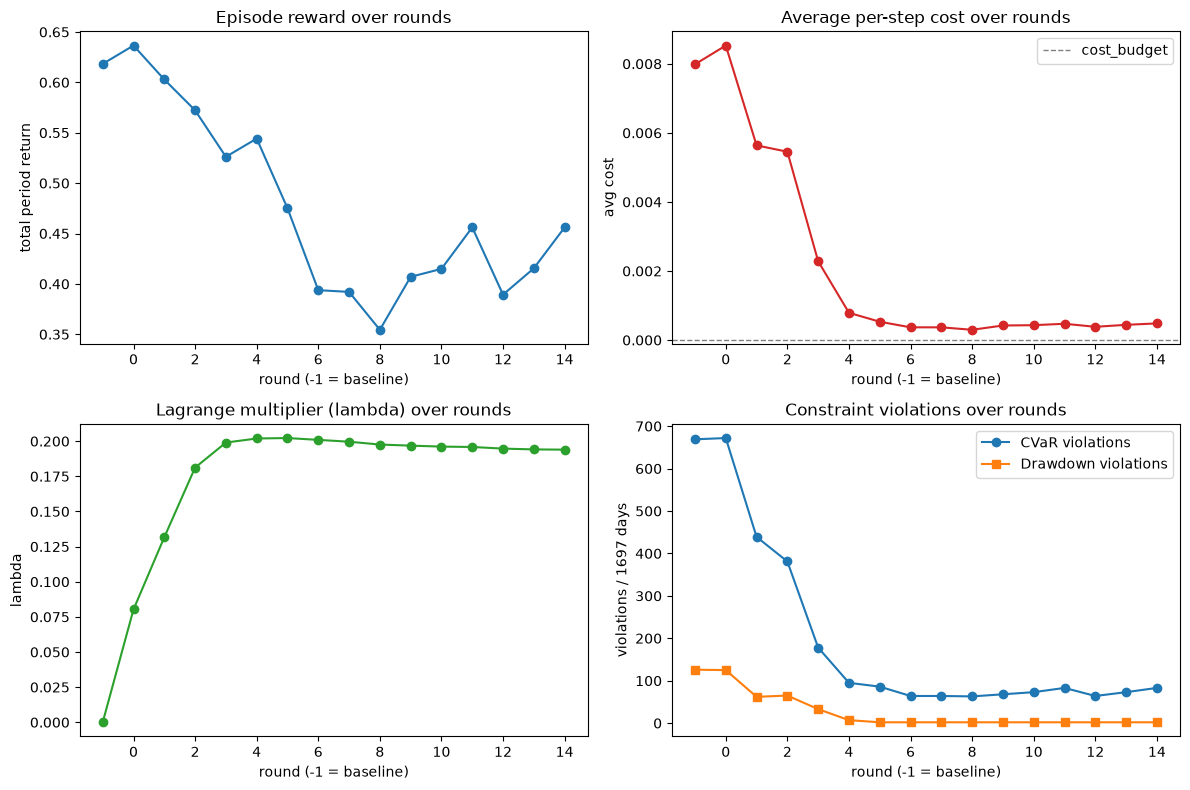

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(history_df["round"], history_df["reward"], marker="o", color="tab:blue")
axes[0, 0].set_title("Episode reward over rounds")
axes[0, 0].set_xlabel("round (-1 = baseline)"); axes[0, 0].set_ylabel("total period return")

axes[0, 1].plot(history_df["round"], history_df["avg_cost"], marker="o", color="tab:red")
axes[0, 1].axhline(0.0, color="gray", ls="--", lw=1, label="cost_budget")
axes[0, 1].set_title("Average per-step cost over rounds")
axes[0, 1].set_xlabel("round (-1 = baseline)"); axes[0, 1].set_ylabel("avg cost"); axes[0, 1].legend()

axes[1, 0].plot(history_df["round"], history_df["lambda"], marker="o", color="tab:green")
axes[1, 0].set_title("Lagrange multiplier (lambda) over rounds")
axes[1, 0].set_xlabel("round (-1 = baseline)"); axes[1, 0].set_ylabel("lambda")

axes[1, 1].plot(history_df["round"], history_df["cvar_violations"], marker="o", label="CVaR violations")
axes[1, 1].plot(history_df["round"], history_df["dd_violations"], marker="s", label="Drawdown violations")
axes[1, 1].set_title("Constraint violations over rounds")
axes[1, 1].set_xlabel("round (-1 = baseline)"); axes[1, 1].set_ylabel(f"violations / {N_STEPS} days"); axes[1, 1].legend()

plt.tight_layout()
plt.show()


## Validate: did the Lagrangian mechanism actually make the policy safer?

The thing this step specifically needs to demonstrate — not "did reward improve" (that was
Step 4's job), but "did the trained-against cost signal actually go down." Compared against the
baseline captured before this notebook's training loop started.


In [10]:
final = history_df.iloc[-1]

print(f"Average per-step cost: {baseline['avg_cost']:.5f} (baseline) -> {final['avg_cost']:.5f} (after training)")
print(f"CVaR violations:       {baseline['cvar_violations']}/{N_STEPS} -> {int(final['cvar_violations'])}/{N_STEPS}")
print(f"Drawdown violations:   {baseline['dd_violations']}/{N_STEPS} -> {int(final['dd_violations'])}/{N_STEPS}")
print(f"Episode reward:        {baseline['reward']:+.2%} -> {final['reward']:+.2%}")

assert final["avg_cost"] < baseline["avg_cost"], \
    "average cost should be lower after Lagrangian training than the untrained-against baseline"
assert final["dd_violations"] <= baseline["dd_violations"], \
    "drawdown violations should not have gotten worse"
print("\nPASS: average cost and drawdown violations both fell relative to the plain-PPO-finetuned "
      "baseline -- the Lagrangian mechanism is training against the constraint, not just observing it")

print(f"\nFor reference: {baseline['cvar_violations'] - final['cvar_violations']:+.0f} fewer CVaR-budget "
      f"violations and {baseline['dd_violations'] - final['dd_violations']:+.0f} fewer drawdown-budget "
      f"violations than the untrained-against baseline, over the same {N_STEPS}-day TRAIN-period episode "
      f"-- with reward moving from {baseline['reward']:+.2%} to {final['reward']:+.2%} in the same run "
      f"(a welcome outcome here if it happens, not a guarantee of this mechanism in general: Step 5's job "
      f"is safety, and reward is free to fall somewhat if that is what satisfying the constraint actually "
      f"requires).")


Average per-step cost: 0.00799 (baseline) -> 0.00048 (after training)
CVaR violations:       669/1697 -> 83/1697
Drawdown violations:   126/1697 -> 2/1697
Episode reward:        +61.83% -> +45.61%

PASS: average cost and drawdown violations both fell relative to the plain-PPO-finetuned baseline -- the Lagrangian mechanism is training against the constraint, not just observing it

For reference: +586 fewer CVaR-budget violations and +124 fewer drawdown-budget violations than the untrained-against baseline, over the same 1697-day TRAIN-period episode -- with reward moving from +61.83% to +45.61% in the same run (a welcome outcome here if it happens, not a guarantee of this mechanism in general: Step 5's job is safety, and reward is free to fall somewhat if that is what satisfying the constraint actually requires).


## A methodological note worth stating plainly — this is the fix, not a leftover caveat

Unlike the original build of this stage, this training run happens on **TRAIN** (2018-2024), not
on the TEST period the final comparison will be scored on. That was the whole point of the
retraining exercise: `Step6B_WalkForwardEvaluation.ipynb` applies this policy, once, at the very
end, to `bl_llm_memory_weights.csv` — the already-optimized TEST-range weights this policy has
never seen in any form during the training above. The numbers in this notebook (reward, cost,
violation counts) are still an honest description of how the *training* run went, on TRAIN — they
are not, and were never meant to be, the final performance claim. That claim is what
`Step6B_WalkForwardEvaluation.ipynb` produces, genuinely out-of-sample this time.


## Save

Ready for Step 6 (packaging `safe_rl_adjust()`) and Step 7 (walk-forward evaluation against
`bl_llm_memory_weights.csv`) in the next session.


In [11]:
model.save("ppo_lagrangian_trained")
history_df.to_csv("lagrangian_training_history.csv", index=False)

print("Saved ppo_lagrangian_trained.zip")
print("Saved lagrangian_training_history.csv")
print(f"\nFinal lambda: {final['lambda']:.4f}")
print(f"Final reward: {final['reward']:+.2%}  (baseline was {baseline['reward']:+.2%})")
print(f"Final avg cost: {final['avg_cost']:.5f}  (baseline was {baseline['avg_cost']:.5f})")
print("\nReady for Step 6 (packaging) and Step 7 (walk-forward evaluation) in the next session.")


Saved ppo_lagrangian_trained.zip
Saved lagrangian_training_history.csv

Final lambda: 0.1940
Final reward: +45.61%  (baseline was +61.83%)
Final avg cost: 0.00048  (baseline was 0.00799)

Ready for Step 6 (packaging) and Step 7 (walk-forward evaluation) in the next session.
